In [81]:
import numpy as np
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals
from sklearn.model_selection import TimeSeriesSplit


Setup

In [82]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
n_trials = 1000
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
# atr_multiplier = 3  # atr multiplier for chandelier exit
# adx_threshold = 25  # trend strength
# ce_high_length = 22  # look back length


# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)
# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close'] / (df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))


                                   close       equity
2025-09-28 12:00:00+00:00  110011.101562  6659.549805
2025-09-28 16:00:00+00:00  110353.203125  6680.258301
2025-09-28 20:00:00+00:00  112127.796875  6787.684570
2025-09-29 00:00:00+00:00  111862.500000  6771.624023
2025-09-29 04:00:00+00:00  111863.601562  6771.690918
2025-09-29 08:00:00+00:00  112093.398438  6785.602051
2025-09-29 12:00:00+00:00  113844.000000  6891.575195
2025-09-29 16:00:00+00:00  114358.296875  6922.708008
2025-09-29 20:00:00+00:00  114365.203125  6923.125977
2025-09-30 00:00:00+00:00  114430.601562  6927.084961


In [83]:
# Train split
n = len(df['close'])
train_size = int(np.floor(n * .4))
test_size = int(np.floor(train_size * .3))  #70/30 split
n_splits = int((n - train_size) // test_size)
print(f"Train/Test Split: {train_size} / {test_size} | N_splits: {n_splits}")
print(f"Train/Test Split (years): {train_size / (6*365):.2f} / {test_size / (6*365):.2f} | N_splits: {n_splits}")
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)


Train/Test Split: 2407 / 722 | N_splits: 5
Train/Test Split (years): 1.10 / 0.33 | N_splits: 5


Optuna setup

In [84]:
def objective(trial: optuna.Trial):
    # Entry
    adx_threshold = trial.suggest_int("adx_threshold", 0, 10)
    adx_length = trial.suggest_int("adx_length", 1, 10)
    # sar_acceleration = trial.suggest_float("sar_acceleration", 0.01, 0.05, step=0.01)
    # sar_maximum = trial.suggest_float("sar_maximum", 0.05, 0.2, step=0.01)

    # Exit
    atr_multiplier = trial.suggest_float("atr_multiplier", .2, 3, step=0.1)
    ce_low_length = trial.suggest_int("ce_low_length", 1, 10)
    # ce_high_length = trial.suggest_int("ce_high_length", 1, 30)
    # atr_length = trial.suggest_int("atr_length", 1, 30)

    s = Signals(adx_threshold=adx_threshold,
                adx_length=adx_length,
                atr_multiplier=atr_multiplier,
                # atr_length=atr_length,
                # ce_high_length=ce_high_length,
                ce_low_length=ce_low_length,
                # sar_acceleration=sar_acceleration,
                # sar_maximum=sar_maximum,
                )

    signals = s.calc_signals(df.copy())
    sortino_list = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(signals), start=1):
        # enforce fixed-length rolling train window
        if len(train_idx) > train_size:
            train_idx = train_idx[-train_size:]
        fold_df = signals.iloc[np.r_[train_idx, val_idx]]

        bt = Backtest(fold_df,
                      interval=interval,
                      transaction_fee=transaction_fee,
                      start_equity=start_equity)
        stats, profit_df = bt.run()

        # Validation
        val_start = len(train_idx)
        val_sortino = bt.sortino_ratio(profit_df['Returns'].iloc[val_start:], interval=interval)

        sortino_list.append(val_sortino)
    sortino = np.mean(sortino_list)
    return sortino

sampler2 = TPESampler(seed=42)
sampler = RandomSampler(seed=42)  # optional seed for reproducibility

study = optuna.create_study(direction="maximize", sampler=sampler, study_name=f"{symbols[0]}-{interval}-{n_trials}")
study.optimize(objective, n_trials=n_trials)

[I 2025-11-07 00:03:00,549] A new study created in memory with name: BTC-4h-1000
[I 2025-11-07 00:03:00,770] Trial 0 finished with value: 6.910029957909776 and parameters: {'adx_threshold': 4, 'adx_length': 10, 'atr_multiplier': 2.3000000000000003, 'ce_low_length': 6}. Best is trial 0 with value: 6.910029957909776.
[I 2025-11-07 00:03:00,980] Trial 1 finished with value: 4.575055448160085 and parameters: {'adx_threshold': 1, 'adx_length': 2, 'atr_multiplier': 0.30000000000000004, 'ce_low_length': 9}. Best is trial 0 with value: 6.910029957909776.
[I 2025-11-07 00:03:01,175] Trial 2 finished with value: 4.250870251191522 and parameters: {'adx_threshold': 6, 'adx_length': 8, 'atr_multiplier': 0.2, 'ce_low_length': 10}. Best is trial 0 with value: 6.910029957909776.
[I 2025-11-07 00:03:01,390] Trial 3 finished with value: 9.567756492036358 and parameters: {'adx_threshold': 9, 'adx_length': 3, 'atr_multiplier': 0.7, 'ce_low_length': 2}. Best is trial 3 with value: 9.567756492036358.
[I 202

Study Results

In [85]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))


|   number |    value |   adx_length |   adx_threshold |   atr_multiplier |   ce_low_length |
|----------|----------|--------------|-----------------|------------------|-----------------|
|      917 | 15.9201  |            5 |               0 |              0.8 |               1 |
|      347 | 15.9201  |            5 |              10 |              0.8 |               1 |
|      854 | 15.7935  |            7 |               3 |              0.8 |               1 |
|      261 | 15.7935  |            7 |               9 |              0.8 |               1 |
|      727 | 15.7136  |            4 |               3 |              0.8 |               1 |
|      393 | 15.6905  |            9 |               8 |              0.8 |               1 |
|      720 | 15.6905  |            9 |               3 |              0.8 |               1 |
|      947 | 15.532   |           10 |               1 |              0.8 |               1 |
|      817 | 14.2934  |            7 |               6 |    

In [86]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sortino: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sortino: 15.92 
|----------------|------|
| adx_threshold  | 10   |
| adx_length     |  5   |
| atr_multiplier |  0.8 |
| ce_low_length  |  1   |


Visualization

In [87]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
show(fig2)



From the slice plot can notice a few things...

- looks like a lowish ce_low_length value is ideal All sortino values > 8 are ce_low_length = 1
- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6
- ADX_length and ADX_threshold appear to perform better at low values

Generally there aren't major correlations, but can generally see where there might be better results.  The slice plot does slightly agree with the most hyperparameter importance, since these are the only values that so some sort of correlation to sortino ratio.


NOTE:  Removed atr_length and ce_high_length from the slice plot, since they have very little correlation to sortino ratio.


In [88]:
# fig4 = optuna.visualization.plot_contour(study)
# fig4.update_layout(height=1000)
# for trace in fig4.data:
#     if hasattr(trace, "marker"):
#         # ensure markers are visible when mode exists
#         if hasattr(trace, "mode") and trace.mode and "markers" not in str(trace.mode):
#             trace.mode = f"{trace.mode}+markers"
#         trace.marker.size = 1
# show(fig4)

# fig3 = optuna.visualization.plot_optimization_history(study)
# show(fig3)

Seaborn plots

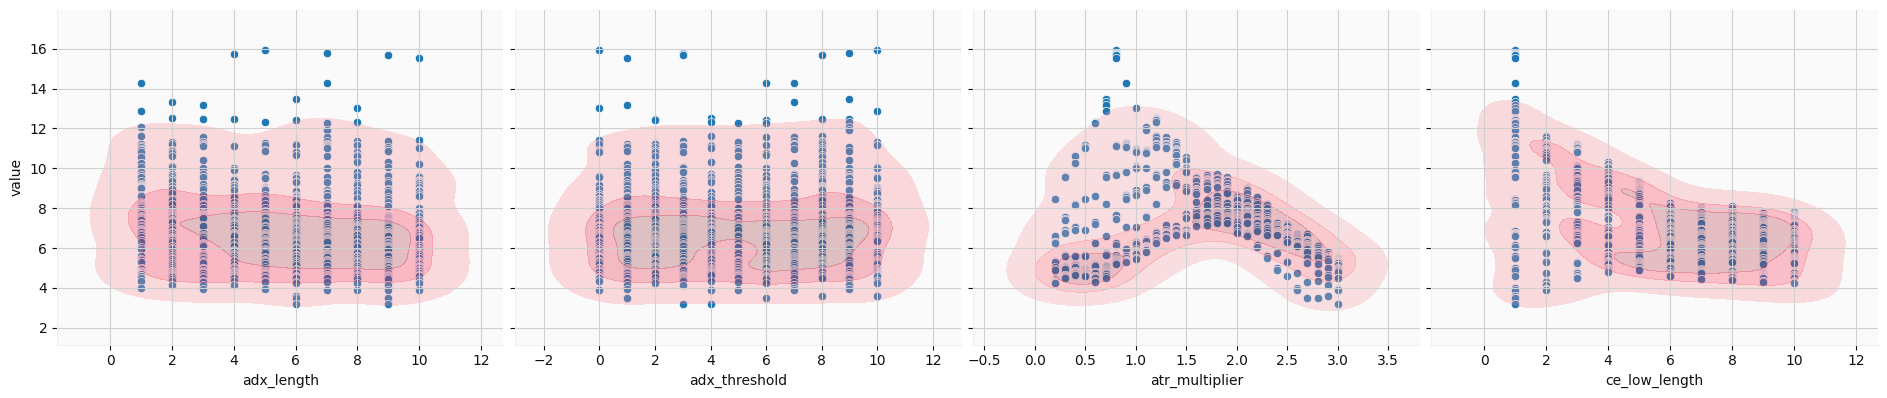

In [89]:
g = sns.pairplot(data=trials,
                 x_vars=trials.columns[2:],
                 y_vars=trials.columns[1],
                 height=4.0,
                 aspect=1.2,

                 )
g.map(sns.kdeplot, levels=4, color='crimson',  fill=True,  alpha=0.3)

plt.show()

Best Trial Backtest

In [90]:
adx_threshold = best_params['adx_threshold']
adx_length = best_params['adx_length']
atr_multiplier = best_params['atr_multiplier']
# atr_length = best_params['atr_length']
# ce_high_length = best_params['ce_high_length']
ce_low_length = best_params['ce_low_length']
# sar_acceleration = best_params['sar_acceleration']
# sar_maximum = best_params['sar_maximum']


s = Signals(adx_threshold=adx_threshold,
            adx_length=adx_length,
            atr_multiplier=atr_multiplier,
            # atr_length=atr_length,
            # ce_high_length=ce_high_length,
            ce_low_length=ce_low_length,
            # sar_acceleration=sar_acceleration,
            # sar_maximum=sar_maximum,
            )
signals = s.calc_signals(df.copy())
bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee)
stats, profit_df = bt.run()
print(f"\n Stats")
print(tabulate(stats.items(), tablefmt="github"))
print(f"\n Profit DataFrame")
print(profit_df.tail().to_string())


 Stats
|------------------|--------------|
| trading_days     |   1003       |
| total_profit     | 153361       |
| total_profit_pct |  15336.1     |
| sharpe           |      6.69468 |
| sortino          |     14.6344  |
| wins             |    243       |
| losses           |     27       |
| win_rate         |     90       |

 Profit DataFrame
                           Entry_Price  Exit_Price          close   Returns  Window_Profit         Equity
2025-09-29 08:00:00+00:00          0.0         0.0  112093.398438  0.002054            NaN  151208.672803
2025-09-29 12:00:00+00:00          0.0         0.0  113844.000000  0.015617            NaN  153570.151200
2025-09-29 16:00:00+00:00          0.0         0.0  114358.296875  0.004518            NaN  154263.913268
2025-09-29 20:00:00+00:00          0.0         0.0  114365.203125  0.000060            NaN  154273.229471
2025-09-30 00:00:00+00:00          0.0         0.0  114430.601562  0.000572       0.033632  154361.448859


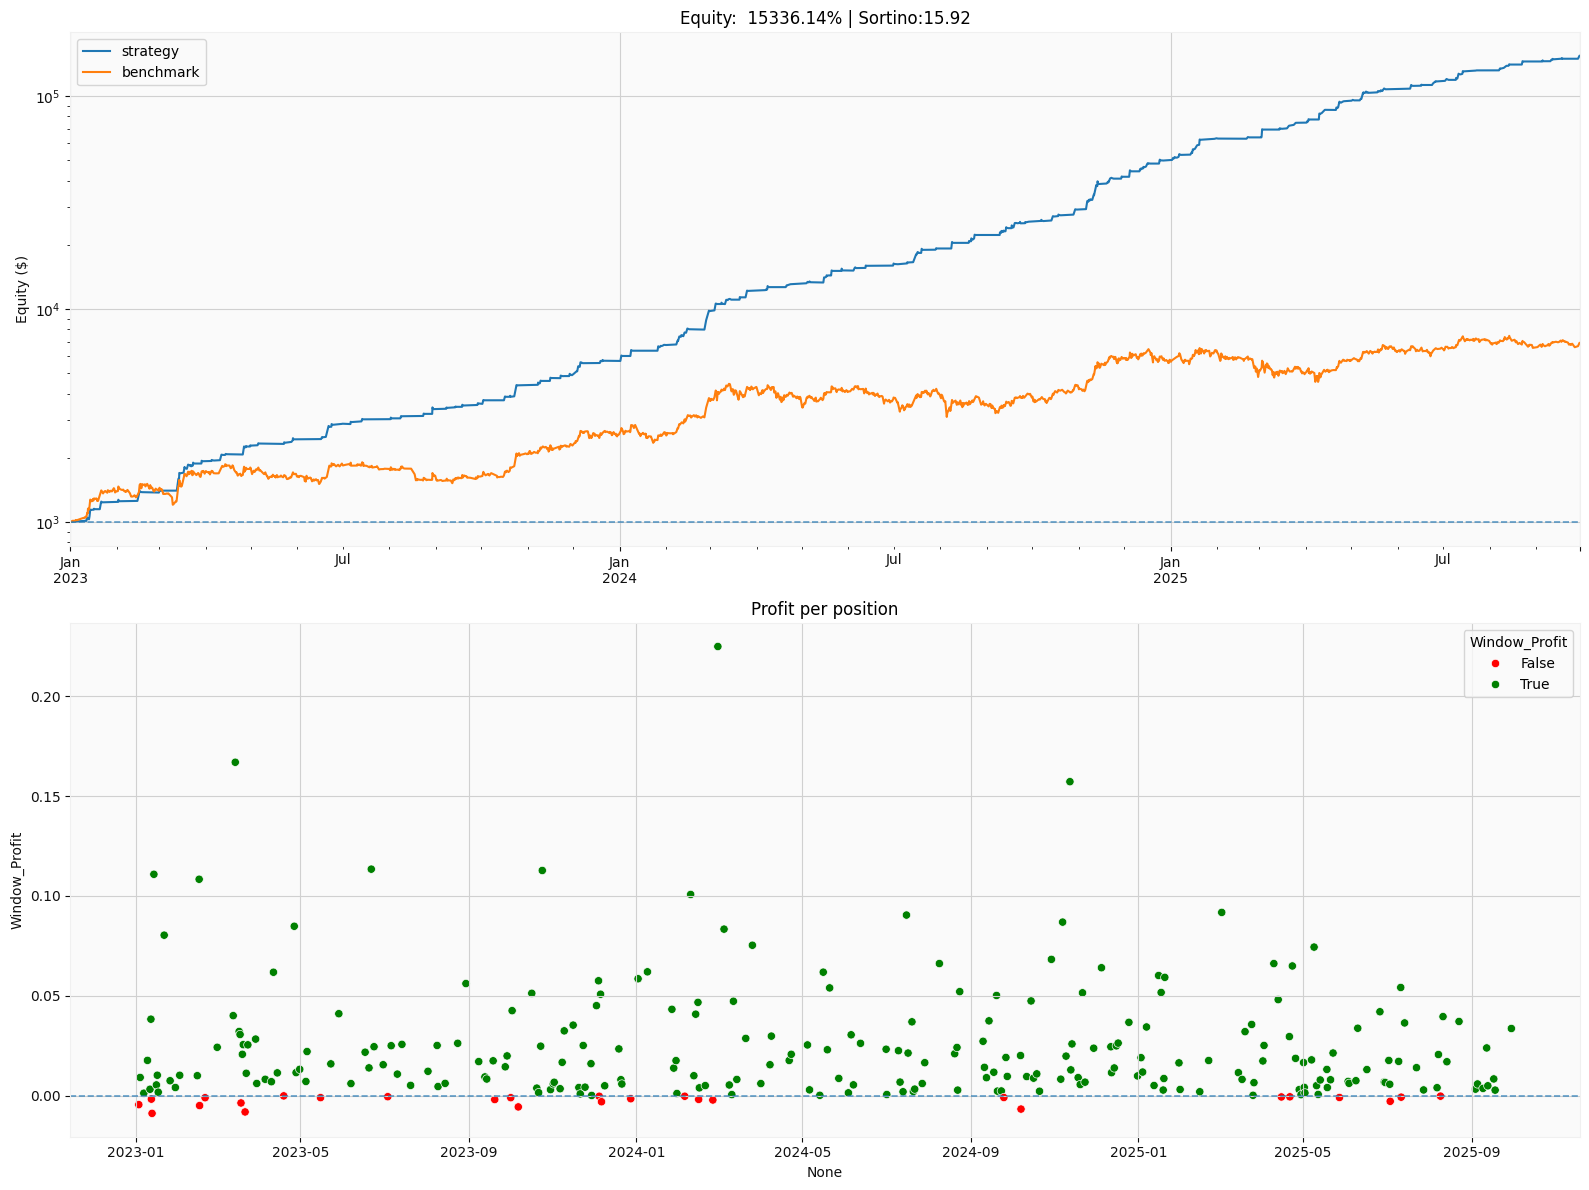

In [91]:
# plots
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
profit_df['Equity'].plot(ax=axes[0], title=f'Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{best_value:.2f}',
                         label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
sns.scatterplot(x=profit_df.index, y='Window_Profit', data=profit_df, ax=axes[1], hue=profit_df['Window_Profit'] > 0,
                palette={True: 'green', False: 'red'})
axes[1].set_title('Profit per position')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
# axes[1].set_yscale('log')
plt.tight_layout()
plt.show()